**Author**: Preethi Deevanapelli

**Tools**: Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

**Objective**:
Predict house prices using a Linear Regression model and evaluate its performance.

1. **Import Libraries**

In [3]:
# Install the dependencies

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

2. **Load the Dataset**

In [4]:
# Download the Dataset
import kagglehub

path = kagglehub.dataset_download("harishkumardatalab/housing-price-prediction")

print("Path to dataset files:", path)

100%|██████████| 4.63k/4.63k [00:00<00:00, 8.32MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/harishkumardatalab/housing-price-prediction/versions/1


In [5]:
# Load the Dataset
df = pd.read_csv(os.path.join(path, "Housing.csv"))

In [6]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [7]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [8]:
df.tail()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


3. **Data Exploration**


In [9]:
df.shape

(545, 13)

In [10]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [11]:
df.dtypes

,0
price,int64
area,int64
bedrooms,int64
bathrooms,int64
stories,int64
mainroad,object
guestroom,object
basement,object
hotwaterheating,object
airconditioning,object


In [12]:
# check for missing values
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


**observations**:


*   Dataset contains 545 rows and 13 columns.
*   No missing values were found.
*   Target variable is price.






4. **Exploratory Data Analysis**

In [13]:
# Statistical Summary
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [14]:
df[df['area'] == df['area'].max()]

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished


In [15]:
df['price'].mean()

np.float64(4766729.247706422)

<Axes: ylabel='Frequency'>

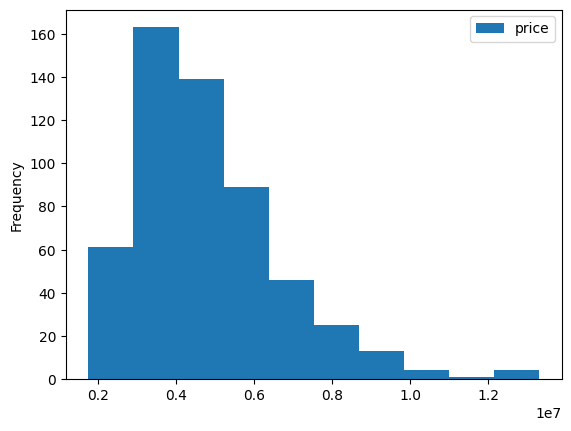

In [16]:
df.plot.hist(y='price')

**Observations**:


*   The Price Distribution is Right Skewed.
*   It is because most houses are clustered in lower to middle price range
*   There are relatively fewer expensive houses creating long tail at right.




In [17]:
df.corr(numeric_only=True)["price"]

,price
price,1.000000
area,0.535997
bedrooms,0.366494
bathrooms,0.517545
stories,0.420712
parking,0.384394


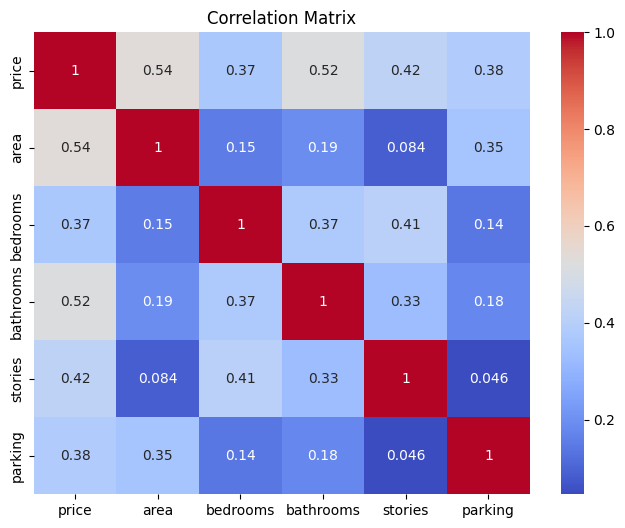

In [18]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot = True, cmap = "coolwarm")
plt.title("Correlation Matrix")
plt.show()

**Observations**:


*   The most correlated column with target column-price is 'area'




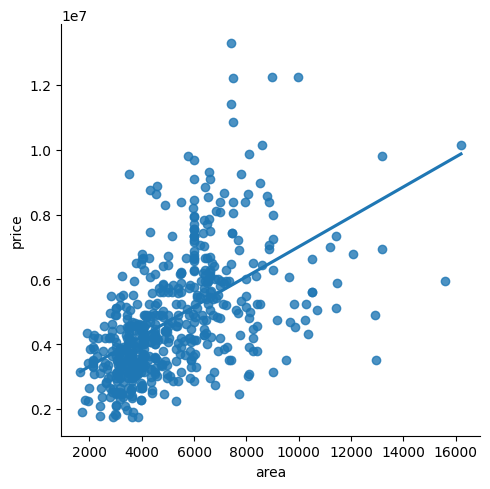

In [19]:
sns.lmplot(x='area', y='price', data=df, fit_reg=True, ci=None)

**Observations**:


*   Area has a linear Relationship with price.



<Axes: >

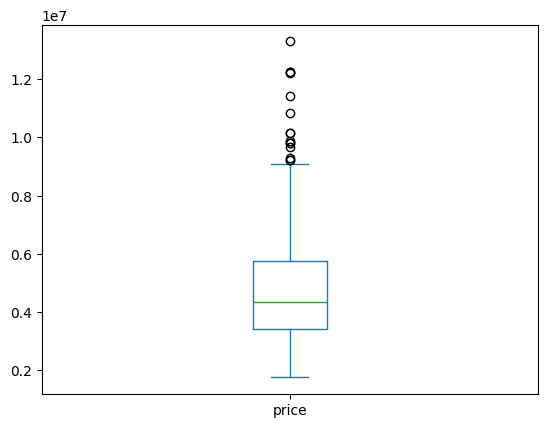

In [20]:
df.plot.box(y='price')

**Observations**:


*   The dots outside the whiskers denotes outliers in the dataset.



4. **Data Preprocessing**

In [21]:
# using label encoding for yes or no columns
yes_no_columns = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

In [22]:
for col in yes_no_columns:
  df[col] = df[col].map({'yes': 1, 'no': 0})

In [23]:
# using One-Hot encoding for 'furnishingstatus' column
df = pd.get_dummies(df, columns=['furnishingstatus'], dtype=int, drop_first=True)

In [24]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,0,1
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1,0
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,0,1
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,0,0


In [25]:
df.dtypes

,0
price,int64
area,int64
bedrooms,int64
bathrooms,int64
stories,int64
mainroad,int64
guestroom,int64
basement,int64
hotwaterheating,int64
airconditioning,int64


In [26]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


5. **Train-Test Split**

In [27]:
# separate features and target
y = df['price']
x = df.drop('price', axis=1)

In [28]:
x.shape, y.shape

((545, 13), (545,))

In [29]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [30]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((436, 13), (109, 13), (436,), (109,))

6. **Train the Model**

In [31]:
# Import the model
model = LinearRegression()

In [32]:
# Train the model
model.fit(x_train, y_train)

LinearRegression()

In [33]:
# Make predictions
y_predict = model.predict(x_test)

In [34]:
y_predict = y_predict.round()

In [35]:
y_predict

array([5164654., 7224722., 3109863., 4612075., 3294646., 3532275.,
       5611775., 6368146., 2722857., 2629406., 9617040., 2798087.,
       3171097., 3394639., 3681089., 5263188., 3035963., 4786123.,
       4349552., 3572362., 5774875., 5886994., 2730836., 4727316.,
       5244848., 7555324., 3220791., 5191899., 8143727., 3398814.,
       6490693., 3315106., 6708457., 4201738., 3557571., 5836975.,
       4808661., 4362879., 3191243., 4596555., 4566043., 3517780.,
       7205845., 3983597., 3749339., 4274731., 6757442., 4037320.,
       3769335., 3417627., 7268417., 2802534., 4341751., 4516422.,
       3679998., 2678959., 7498029., 2920366., 4239582., 2766467.,
       4841310., 3584360., 5142141., 4221869., 4698409., 4662381.,
       7177842., 3452199., 5902437., 6198094., 4773219., 5178933.,
       4490411., 7968737., 3519395., 5501905., 3947055., 4714056.,
       4792291., 4250597., 7718149., 4053241., 6453919., 5355572.,
       2755188., 6796008., 2607277., 3679739., 7968276., 80784

In [36]:
# compare Actual vs Predicted prices
comparision = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_predict
})
comparision.head(10)

,Actual,Predicted
316,4060000,5164654.0
77,6650000,7224722.0
360,3710000,3109863.0
90,6440000,4612075.0
493,2800000,3294646.0
209,4900000,3532275.0
176,5250000,5611775.0
249,4543000,6368146.0
516,2450000,2722857.0
426,3353000,2629406.0


7. **Model Evaluation**

In [37]:
mae = mean_absolute_error(y_test, y_predict)
mse = mean_squared_error(y_test, y_predict)


In [38]:
mae

970043.4220183486

In [39]:
y_test.describe().round()

,price
count,109.0
mean,5007537.0
std,2258622.0
min,1750000.0
25%,3290000.0
50%,4550000.0
75%,6510000.0
max,13300000.0


In [40]:
mse

1754318743911.4587

In [41]:
import numpy as np
rmse = np.sqrt(mse)

In [42]:
rmse

np.float64(1324506.9814506297)

In [43]:
r2 = r2_score(y_test, y_predict)
r2

0.6529242530213312

Observations:


*   The model achieved an R² score of 0.653, explaining approximately 65% of the variance in house prices.


In [44]:
model.intercept_

np.float64(260032.35760741122)

In [45]:
model.coef_

array([ 2.35968805e+02,  7.67787016e+04,  1.09444479e+06,  4.07476595e+05,
        3.67919948e+05,  2.31610037e+05,  3.90251176e+05,  6.84649885e+05,
        7.91426736e+05,  2.24841913e+05,  6.29890565e+05, -1.26881818e+05,
       -4.13645062e+05])

In [46]:
coef_df = pd.DataFrame({
    "Features": x.columns,
    "coefficient": model.coef_
})

In [47]:
coef_df = coef_df.sort_values(by='coefficient', ascending=False)

In [48]:
coef_df = coef_df.round()

8. **Feature Importance**

In [49]:
coef_df

,Features,coefficient
2,bathrooms,1094445.0
8,airconditioning,791427.0
7,hotwaterheating,684650.0
10,prefarea,629891.0
3,stories,407477.0
6,basement,390251.0
4,mainroad,367920.0
5,guestroom,231610.0
9,parking,224842.0
1,bedrooms,76779.0


**observations**:


*   Bathrooms have the highest positive coefficient.
*   Unfurnished houses have a negative coefficient relative to the reference category.




**Conclusion**:

This project demonstrates an end-to-end Linear Regression workflow including preprocessing, visualization, model training, evaluation, and interpretation. Future work could compare this model with Decision Trees and Random Forests.